# 01 · Análisis exploratorio del catálogo sísmico de Mendoza

Este notebook realiza el primer análisis exploratorio reproducible del catálogo procesado v1.1. El CSV se trata como una **entrada inmutable**: se lee, se validan sus campos y se documentan los problemas encontrados, pero no se corrigen ni eliminan registros automáticamente.

Los subconjuntos usados a lo largo del análisis son:

- **Catálogo completo:** todos los registros del CSV.
- **Eventos QC:** `event_qc_ready == 'yes'`.
- **Subconjunto analítico Mw:** `mw_analysis_ready == 'yes'` y `mw_reference` válida.
- **Subconjunto espacial válido:** eventos QC, dentro del rectángulo solicitado y con coordenadas físicamente válidas.


In [ ]:
from __future__ import annotations

import hashlib
from pathlib import Path

import matplotlib.pyplot as plt # Maneja gráficos y visualizaciones
import numpy as np # Maneja arreglos y operaciones matemáticas
import pandas as pd # Maneja tablas y datos
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 5.5)
plt.rcParams['axes.titleweight'] = 'bold'


Matplotlib is building the font cache; this may take a moment.


## 1. Carga reproducible

La raíz se busca por la presencia simultánea de `pyproject.toml` y `data/processed`. Esto permite ejecutar el notebook desde la raíz del repositorio o desde `notebooks/`, sin rutas absolutas. La codificación `utf-8-sig` admite explícitamente el BOM del CSV.


In [ ]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'data' / 'processed').is_dir():
            return candidate
    raise FileNotFoundError('No se encontró la raíz del proyecto desde el directorio actual.')


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()


PROJECT_ROOT = find_project_root()
CSV_PATH = PROJECT_ROOT / 'data' / 'processed' / 'catalogo_sismico_mendoza_v1.1_final.csv' # Define la ruta del archivo CSV esperado para que lo pueda leer.
if not CSV_PATH.is_file():
    raise FileNotFoundError(f'No existe el catálogo esperado: {CSV_PATH}')

csv_sha256_before = sha256_file(CSV_PATH)
print(f'Raíz del proyecto detectada: {PROJECT_ROOT.name}')
print(f'Entrada: {CSV_PATH.relative_to(PROJECT_ROOT)}')
print(f'SHA-256 inicial: {csv_sha256_before}')


Raíz del proyecto detectada: proyecto-sismico-mendoza
Entrada: data\processed\catalogo_sismico_mendoza_v1.1_final.csv
SHA-256 inicial: 702b71e1789967881dc380ca5aea02c279863e7bf00df256454ad142cf3ae228


In [ ]:
required_columns = { # Validaciones Iniciales
    'catalog_id', 'time_utc', 'year', 'month', 'latitude', 'longitude', 'depth_km',
    'magnitude_original', 'magnitude_type_original', 'magnitude_type_std',
    'mw_reference', 'mw_reference_method', 'mw_reference_source',
    'mw_reference_status', 'primary_source', 'sources', 'source_count',
    'isc_event_id', 'usgs_event_id', 'spatial_qc', 'match_qc',
    'event_qc_ready', 'mw_analysis_ready', 'qc_notes',
}

raw_catalog = pd.read_csv(CSV_PATH, encoding='utf-8-sig', low_memory=False)
missing_columns = sorted(required_columns.difference(raw_catalog.columns)) # Pregunta si falta alguna columna obligatoria
if missing_columns:
    raise ValueError(f'Faltan columnas obligatorias: {missing_columns}')

catalog = raw_catalog.copy()
original_time = catalog['time_utc'].copy()
catalog['time_utc'] = pd.to_datetime(catalog['time_utc'], errors='coerce', utc=True)
numeric_columns = [
    'year', 'month', 'latitude', 'longitude', 'depth_km',
    'magnitude_original', 'mw_reference', 'source_count',
]
for column in numeric_columns:
    catalog[column] = pd.to_numeric(catalog[column], errors='coerce')

print(f'Filas: {len(catalog):,} | Columnas: {catalog.shape[1]}')
display(catalog.head(3))


Filas: 4,623 | Columnas: 24


,catalog_id,time_utc,year,month,latitude,longitude,depth_km,magnitude_original,magnitude_type_original,magnitude_type_std,mw_reference,mw_reference_method,mw_reference_source,mw_reference_status,primary_source,sources,source_count,isc_event_id,usgs_event_id,spatial_qc,match_qc,event_qc_ready,mw_analysis_ready,qc_notes
0,MZA-00001,2000-01-04 15:10:56.560000+00:00,2000,1,-33.322,-68.525,43.400,4.300,MD,MD,4.274,Mendoza2022_Meq_to_Mw,Mendoza/YPF 2022,converted_regional,ISC,ISC,1,"2,058,043.000",NaN,inside_rectangle,single_source,yes,yes,NaN
1,MZA-00002,2000-01-05 16:05:52.120000+00:00,2000,1,-32.167,-69.873,147.300,3.700,MD,MD,3.692,Mendoza2022_Meq_to_Mw,Mendoza/YPF 2022,converted_regional,ISC,ISC,1,"2,058,065.000",NaN,inside_rectangle,single_source,yes,yes,NaN
2,MZA-00003,2000-01-08 08:02:59.740000+00:00,2000,1,-33.252,-68.870,13.300,3.400,MD,MD,3.401,Mendoza2022_Meq_to_Mw,Mendoza/YPF 2022,converted_regional,ISC,ISC,1,"2,058,098.000",NaN,inside_rectangle,single_source,yes,yes,NaN


## 2. Resumen general y subconjuntos

Las máscaras respetan las decisiones ya materializadas en las columnas QC; no intentan reinterpretarlas ni reparar registros.
Catalogo completo: los 623 eventos.
Eventos QC: Eventos aptos para el analisis general.
Subconjunto Mw: Eventos que ademas tienen una mw_reference valida y pasan el QC necesario para el analisis de magnitud

In [ ]:
def equals_normalized(series: pd.Series, value: str) -> pd.Series:
    return series.astype('string').str.strip().str.casefold().eq(value.casefold()).fillna(False)


event_qc_mask = equals_normalized(catalog['event_qc_ready'], 'yes') # Evento apto para analisis general, solo devuelve True si el evento tiene un valor de magnitud de momento (Mw) registrado.
mw_ready_mask = equals_normalized(catalog['mw_analysis_ready'], 'yes') & catalog['mw_reference'].notna() # Evento apto para analisis de magnitud de momento (Mw), solo devuelve True si el evento tiene un valor de magnitud de momento (Mw) registrado.
physical_coordinates_mask = catalog['latitude'].between(-90, 90) & catalog['longitude'].between(-180, 180)
inside_rectangle_mask = equals_normalized(catalog['spatial_qc'], 'inside_rectangle')
spatial_valid_mask = event_qc_mask & inside_rectangle_mask & physical_coordinates_mask

# Porque tenemos 2 filtros distintos ya que un evento puede ser valido geograficamente y temproralmente, péro no tener una magnitud adecuada para el analisis de magnitud de momento (Mw). 


catalog_qc = catalog.loc[event_qc_mask].copy()
catalog_mw = catalog.loc[mw_ready_mask].copy()
catalog_spatial = catalog.loc[spatial_valid_mask].copy()

status = catalog['mw_reference_status'].astype('string').str.strip().str.casefold()
summary = pd.Series({
    'Eventos totales': len(catalog),
    'Inicio de cobertura': catalog['time_utc'].min(),
    'Fin de cobertura': catalog['time_utc'].max(),
    'IDs únicos': catalog['catalog_id'].nunique(dropna=True),
    'Eventos que pasan QC': int(event_qc_mask.sum()),
    'Eventos listos para análisis Mw': int(mw_ready_mask.sum()),
    'Subconjunto espacial válido': int(spatial_valid_mask.sum()),
    'Mw directas': int(status.eq('direct').sum()),
    'Mw convertidas': int(status.str.startswith('converted', na=False).sum()),
    'Mw excluidas': int(status.str.startswith('excluded', na=False).sum()),
    'Eventos integrados ISC + USGS': int(equals_normalized(catalog['sources'], 'ISC + USGS').sum()),
}, name='valor')
display(summary.to_frame())


,valor
Eventos totales,4623
Inicio de cobertura,2000-01-04 15:10:56.560000+00:00
Fin de cobertura,2025-12-29 02:06:38.539000+00:00
IDs únicos,4623
Eventos que pasan QC,4572
Eventos listos para análisis Mw,4523
Subconjunto espacial válido,4572
Mw directas,13
Mw convertidas,4556
Mw excluidas,54


In [5]:
subset_overview = pd.DataFrame({
    'subconjunto': ['Catálogo completo', 'Eventos QC', 'Analítico Mw', 'Espacial válido'],
    'eventos': [len(catalog), len(catalog_qc), len(catalog_mw), len(catalog_spatial)],
})
subset_overview['porcentaje_del_total'] = 100 * subset_overview['eventos'] / len(catalog)
display(subset_overview)


,subconjunto,eventos,porcentaje_del_total
0,Catálogo completo,4623,100.000
1,Eventos QC,4572,98.897
2,Analítico Mw,4523,97.837
3,Espacial válido,4572,98.897


## 3. Controles de calidad

Los controles siguientes son diagnósticos. Los registros señalados permanecen en memoria y en el archivo de entrada; cualquier exclusión analítica se realiza mediante máscaras explícitas.


In [6]:
blank_counts = pd.Series(0, index=raw_catalog.columns, dtype='int64')
text_columns = raw_catalog.select_dtypes(include=['object', 'string']).columns
blank_counts.loc[text_columns] = raw_catalog[text_columns].apply(
    lambda values: values.astype('string').str.strip().eq('').sum()
)
missing_or_blank = raw_catalog.isna().sum().add(blank_counts, fill_value=0).astype(int)
missing_table = pd.DataFrame({
    'faltantes': missing_or_blank,
    'porcentaje': 100 * missing_or_blank / len(raw_catalog),
}).sort_values(['faltantes', 'porcentaje'], ascending=False)
display(missing_table)


,faltantes,porcentaje
qc_notes,4523,97.837
usgs_event_id,3490,75.492
mw_reference,54,1.168
mw_reference_source,54,1.168
magnitude_type_original,37,0.800
magnitude_type_std,37,0.800
isc_event_id,35,0.757
magnitude_original,33,0.714
catalog_id,0,0.000
time_utc,0,0.000


In [7]:
duplicate_id_mask = catalog['catalog_id'].duplicated(keep=False) | catalog['catalog_id'].isna()
invalid_date_mask = catalog['time_utc'].isna()
invalid_coordinate_mask = ~physical_coordinates_mask | catalog[['latitude', 'longitude']].isna().any(axis=1)
extreme_depth_mask = catalog['depth_km'].lt(0) | catalog['depth_km'].gt(300)
missing_original_magnitude_mask = catalog['magnitude_original'].isna()
missing_reference_magnitude_mask = catalog['mw_reference'].isna()
outside_rectangle_mask = ~inside_rectangle_mask

quality_issues = pd.DataFrame({
    'control': [
        'Filas con ID duplicado o faltante',
        'Fechas inválidas',
        'Coordenadas faltantes o fuera de rango físico',
        'Profundidades negativas o mayores a 300 km',
        'Magnitudes originales faltantes',
        'Mw de referencia faltantes',
        'Registros fuera del rectángulo solicitado',
    ],
    'registros': [
        int(duplicate_id_mask.sum()), int(invalid_date_mask.sum()),
        int(invalid_coordinate_mask.sum()), int(extreme_depth_mask.sum()),
        int(missing_original_magnitude_mask.sum()), int(missing_reference_magnitude_mask.sum()),
        int(outside_rectangle_mask.sum()),
    ],
})
quality_issues['porcentaje'] = 100 * quality_issues['registros'] / len(catalog)
display(quality_issues)


,control,registros,porcentaje
0,Filas con ID duplicado o faltante,0,0.000
1,Fechas inválidas,0,0.000
2,Coordenadas faltantes o fuera de rango físico,0,0.000
3,Profundidades negativas o mayores a 300 km,2,0.043
4,Magnitudes originales faltantes,33,0.714
5,Mw de referencia faltantes,54,1.168
6,Registros fuera del rectángulo solicitado,1,0.022


In [ ]:
diagnostic_mask = (
    duplicate_id_mask | invalid_date_mask | invalid_coordinate_mask | extreme_depth_mask
    | missing_original_magnitude_mask | missing_reference_magnitude_mask | outside_rectangle_mask
)
diagnostic_columns = [
    'catalog_id', 'time_utc', 'latitude', 'longitude', 'depth_km',
    'magnitude_original', 'mw_reference', 'spatial_qc',
    'event_qc_ready', 'mw_analysis_ready', 'qc_notes',
]
print(f'Registros señalados por al menos un control: {int(diagnostic_mask.sum()):,}') # En este caso se muestra los eventos que al menos alguna condicion para ser inspeccionado.
display(catalog.loc[diagnostic_mask, diagnostic_columns].head(20)) 

# El dato faltante es indicado en la parte de qc_notes, que es un campo de texto libre donde se registran las observaciones de los controles de calidad.

Registros señalados por al menos un control: 57


,catalog_id,time_utc,latitude,longitude,depth_km,magnitude_original,mw_reference,spatial_qc,event_qc_ready,mw_analysis_ready,qc_notes
6,MZA-00007,2000-01-23 08:31:49.490000+00:00,-32.984,-69.796,129.300,NaN,NaN,inside_rectangle,yes,no,Magnitud QC: missing.
8,MZA-00009,2000-02-09 04:10:35.420000+00:00,-32.356,-69.717,130.600,NaN,NaN,inside_rectangle,yes,no,Magnitud QC: missing.
9,MZA-00010,2000-02-18 23:28:35.660000+00:00,-33.424,-68.694,27.800,NaN,NaN,inside_rectangle,yes,no,Magnitud QC: missing.
15,MZA-00016,2000-03-11 11:03:58.050000+00:00,-33.153,-69.027,11.400,NaN,NaN,inside_rectangle,yes,no,Magnitud QC: missing.
22,MZA-00023,2000-03-20 10:32:05.530000+00:00,-32.181,-69.851,153.300,NaN,NaN,inside_rectangle,no,no,Match cauteloso; excluir del análisis espacial...
32,MZA-00033,2000-05-14 01:46:00.780000+00:00,-33.010,-68.992,15.000,NaN,NaN,inside_rectangle,yes,no,Magnitud QC: missing.
52,MZA-00053,2000-08-15 21:07:22.160000+00:00,-32.725,-69.250,170.800,NaN,NaN,inside_rectangle,yes,no,Magnitud QC: missing.
56,MZA-00057,2000-09-08 17:57:30.100000+00:00,-32.697,-68.808,19.900,NaN,NaN,inside_rectangle,yes,no,Magnitud QC: missing.
66,MZA-00067,2000-10-15 15:21:37.200000+00:00,-33.137,-69.538,30.500,NaN,NaN,inside_rectangle,yes,no,Magnitud QC: missing.
70,MZA-00071,2000-11-19 19:09:50.500000+00:00,-33.389,-68.125,0.000,NaN,NaN,inside_rectangle,yes,no,Magnitud QC: missing.


In [9]:
qc_columns = ['event_qc_ready', 'mw_analysis_ready', 'spatial_qc', 'match_qc', 'mw_reference_status']
qc_distributions = pd.concat(
    {column: catalog[column].value_counts(dropna=False) for column in qc_columns},
    names=['campo', 'valor'],
).rename('eventos').reset_index()
qc_distributions['porcentaje_dentro_del_campo'] = qc_distributions.groupby('campo')['eventos'].transform(
    lambda values: 100 * values / values.sum()
)
display(qc_distributions)


,campo,valor,eventos,porcentaje_dentro_del_campo
0,event_qc_ready,yes,4572,98.897
1,event_qc_ready,no,51,1.103
2,mw_analysis_ready,yes,4523,97.837
3,mw_analysis_ready,no,100,2.163
4,spatial_qc,inside_rectangle,4622,99.978
5,spatial_qc,outside_requested_rectangle,1,0.022
6,match_qc,single_source,3525,76.249
7,match_qc,accepted_auto,1051,22.734
8,match_qc,accepted_manual_strong,30,0.649
9,match_qc,accepted_manual_location_uncertainty,14,0.303


## 4. Análisis temporal

> Las variaciones en el número de registros no deben interpretarse automáticamente como cambios de sismicidad. También pueden reflejar cambios en cobertura instrumental, fuentes, criterios de reporte y completitud del catálogo.

> Cuando vemos que un año tuvo, por asi decirlo, mas eventos registrados. Esto no quiere decir que ese año tuvo mas actividad sismica, sino que la explicacion de esto es que en ese momento pudo haber mejor cobertura de estaciones, cambios en los catalogos, incorporacion de otras agencias, etc.


año,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Catálogo completo,85,173,172,150,129,163,152,113,89,73,325,570,709,463,85,29,44,104,260,273,61,95,52,161,54,39
Eventos QC,84,173,171,149,129,163,152,113,89,73,325,570,709,463,85,29,44,104,259,273,61,95,52,161,35,11
Subconjunto Mw,74,161,166,145,127,163,146,113,89,73,325,570,709,463,85,29,41,103,258,273,61,94,50,160,34,11


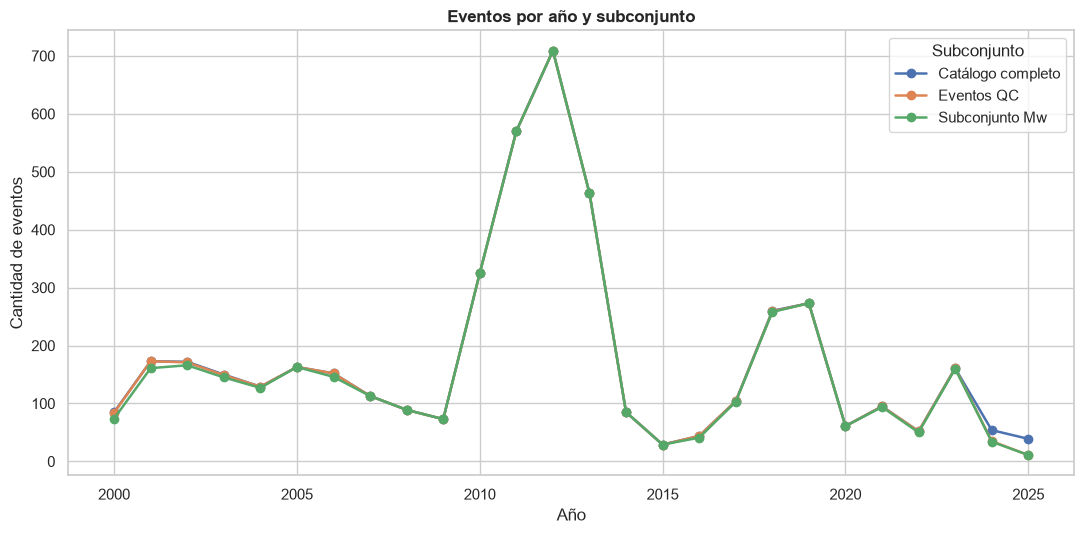

In [ ]:

# Analizamos la distribución temporal para detectar cambios en la
# cantidad de registros y posibles variaciones en la cobertura del catálogo.

valid_years = catalog['time_utc'].dropna().dt.year
year_index = pd.Index(range(int(valid_years.min()), int(valid_years.max()) + 1), name='año')

def counts_by_year(frame: pd.DataFrame) -> pd.Series:
    return frame['time_utc'].dropna().dt.year.value_counts().reindex(year_index, fill_value=0).sort_index()

# Comparamos catálogo completo, eventos QC y subconjunto Mw para verificar
# cuánto afectan los filtros de calidad a cada año.
annual_counts = pd.DataFrame({
    'Catálogo completo': counts_by_year(catalog), # Catalogo completo: todos los eventos unicos.
    'Eventos QC': counts_by_year(catalog_qc), # Eventos QC: solos los que pasan el control de calidad general.
    'Subconjunto Mw': counts_by_year(catalog_mw), # Subconjunto Mw: los que ademas pueden analizarse con magnitud de momento (Mw).
})
display(annual_counts.T)
ax = annual_counts.plot(marker='o', linewidth=1.8)
ax.set(title='Eventos por año y subconjunto', xlabel='Año', ylabel='Cantidad de eventos')
ax.legend(title='Subconjunto')
plt.tight_layout()
plt.show()


,Catálogo completo,Eventos QC,Subconjunto Mw
mes,,,
1,467,464,462
2,440,438,431
3,318,311,308
4,318,315,314
5,349,347,341
6,348,341,338
7,299,299,295
8,342,338,334
9,392,388,384


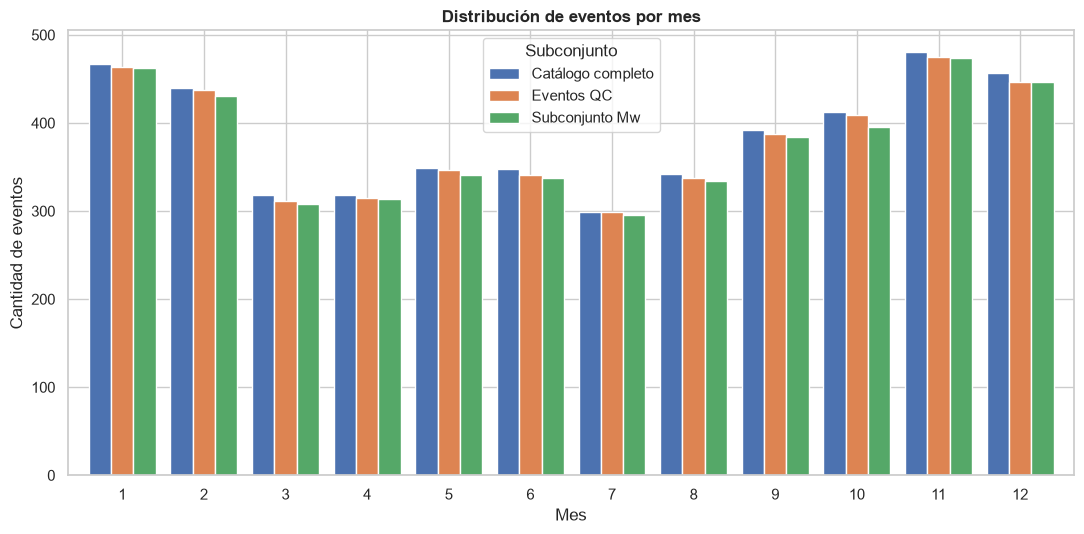

In [ ]:

# La distribución mensual se utiliza de forma descriptiva.
# No se interpreta como evidencia de estacionalidad sísmica sin
# un análisis estadístico específico que la respalde.

month_index = pd.Index(range(1, 13), name='mes')

def counts_by_month(frame: pd.DataFrame) -> pd.Series:
    return frame['time_utc'].dropna().dt.month.value_counts().reindex(month_index, fill_value=0).sort_index()

monthly_counts = pd.DataFrame({
    'Catálogo completo': counts_by_month(catalog),
    'Eventos QC': counts_by_month(catalog_qc),
    'Subconjunto Mw': counts_by_month(catalog_mw),
})
display(monthly_counts)
ax = monthly_counts.plot(kind='bar', width=0.82)
ax.set(title='Distribución de eventos por mes', xlabel='Mes', ylabel='Cantidad de eventos')
ax.legend(title='Subconjunto')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Magnitudes

El análisis usa el subconjunto marcado como listo para Mw. La magnitud original, su tipo, el método, la fuente y el estado de la conversión permanecen visibles para preservar la trazabilidad.


,mw_reference
count,"4,523.000"
mean,2.752
std,0.807
min,0.394
5%,1.558
25%,2.139
50%,2.721
75%,3.401
95%,4.080
max,5.700


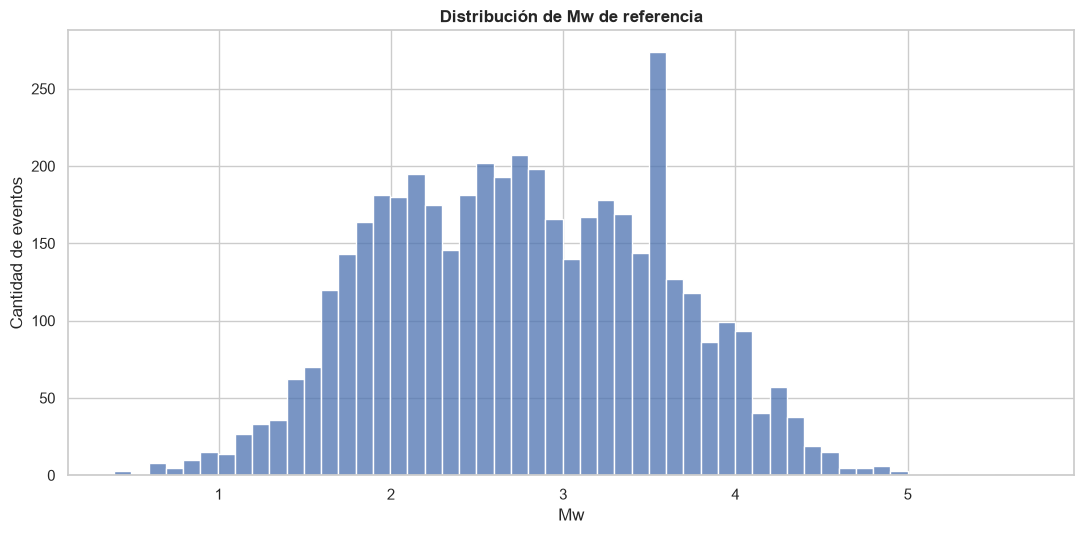

In [ ]:
mw_values = catalog_mw['mw_reference'].dropna()
mw_statistics = mw_values.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame('mw_reference')
display(mw_statistics)

fig, ax = plt.subplots()
sns.histplot(mw_values, binwidth=0.1, edgecolor='white', ax=ax)
ax.set(title='Distribución de Mw de referencia', xlabel='Mw', ylabel='Cantidad de eventos')
plt.tight_layout()
plt.show()

# Se describe la distribución de Mw sobre el subconjunto que pasa
# los controles de calidad y posee una Mw comparable.
# El histograma permite observar la frecuencia de eventos por magnitud.
# Su forma será utilizada posteriormente para estimar la magnitud
# de completitud (Mc).

,eventos,media,mediana,minimo,maximo,desviacion
origen_mw,,,,,,
Convertida,4510,2.749,2.721,0.394,5.340,0.802
Directa,13,3.992,4.400,1.600,5.700,1.319


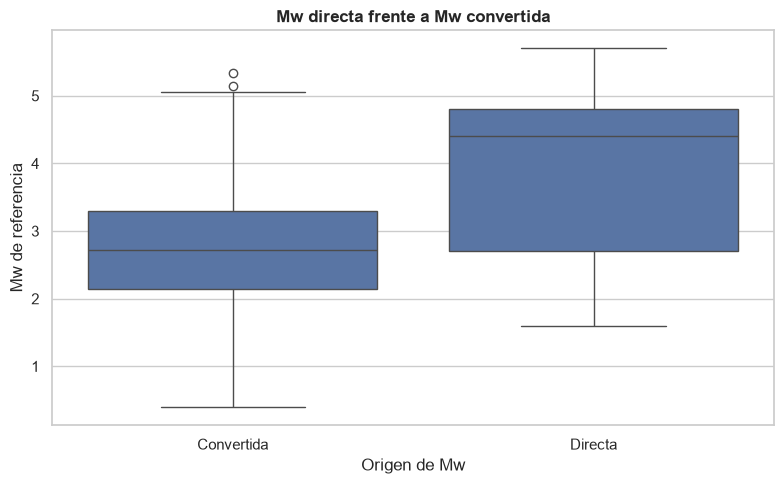

La comparación es descriptiva: debe interpretarse junto con el tamaño de cada grupo y su cobertura.


In [ ]:
mw_origin = np.select(
    [
        catalog_mw['mw_reference_status'].astype('string').str.casefold().eq('direct'),
        catalog_mw['mw_reference_status'].astype('string').str.casefold().str.startswith('converted', na=False),
    ],
    ['Directa', 'Convertida'],
    default='Otro estado',
)
magnitude_comparison = catalog_mw.assign(origen_mw=mw_origin)
comparison_statistics = magnitude_comparison.groupby('origen_mw', observed=True)['mw_reference'].agg(
    eventos='count', media='mean', mediana='median', minimo='min', maximo='max', desviacion='std'
)
display(comparison_statistics)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=magnitude_comparison, x='origen_mw', y='mw_reference', ax=ax)
ax.set(title='Mw directa frente a Mw convertida', xlabel='Origen de Mw', ylabel='Mw de referencia')
plt.tight_layout()
plt.show()
print('La comparación es descriptiva: debe interpretarse junto con el tamaño de cada grupo y su cobertura.')

# La comparación entre Mw directas y convertidas es descriptiva.
# El número de Mw reportadas directamente es muy pequeño respecto
# del número de magnitudes convertidas, por lo que no se infieren
# diferencias estadísticas fuertes entre ambos grupos.


In [ ]:
traceability_columns = [
    'catalog_id', 'time_utc', 'latitude', 'longitude', 'depth_km',
    'magnitude_original', 'magnitude_type_original', 'mw_reference',
    'mw_reference_method', 'mw_reference_source', 'mw_reference_status', 'sources',
]
largest_events = catalog_mw.sort_values(
    ['mw_reference', 'time_utc'], ascending=[False, True]
).loc[:, traceability_columns].head(15)
display(largest_events)

# mw_reference_source = bibliografía utilizada para convertir la magnitud a Mw.

,catalog_id,time_utc,latitude,longitude,depth_km,magnitude_original,magnitude_type_original,mw_reference,mw_reference_method,mw_reference_source,mw_reference_status,sources
990,MZA-00991,2006-09-24 21:08:49.500000+00:00,-32.228,-67.687,141.000,5.700,mwb,5.700,reported_Mw,ISC/USGS,direct,USGS
4567,MZA-04568,2024-11-03 04:04:04.506000+00:00,-35.697,-69.493,188.150,5.400,mww,5.400,reported_Mw,ISC/USGS,direct,ISC + USGS
1549,MZA-01550,2010-10-17 14:40:14.399000+00:00,-32.083,-69.491,110.800,5.400,ML,5.340,Mendoza2022_Meq_to_Mw,Mendoza/YPF 2022,converted_regional,ISC
3452,MZA-03453,2015-02-02 10:49:48.439000+00:00,-32.648,-67.150,172.700,6.100,mb,5.144,Mendoza2022_mb_to_Mw,Mendoza/YPF 2022,converted_regional,ISC + USGS
1551,MZA-01552,2010-10-17 15:50:17.500000+00:00,-33.475,-68.582,25.700,5.100,ML,5.050,Mendoza2022_Meq_to_Mw,Mendoza/YPF 2022,converted_regional,ISC
959,MZA-00960,2006-08-05 14:03:43.600000+00:00,-33.118,-68.786,21.600,5.800,mb,4.978,Mendoza2022_mb_to_Mw,Mendoza/YPF 2022,converted_regional,ISC + USGS
1819,MZA-01820,2011-05-09 01:13:21.300000+00:00,-32.415,-67.933,125.800,5.000,ML,4.952,Mendoza2022_Meq_to_Mw,Mendoza/YPF 2022,converted_regional,ISC
3516,MZA-03517,2016-11-13 17:52:53+00:00,-32.007,-68.106,113.480,4.900,mwr,4.900,reported_Mw,ISC/USGS,direct,USGS
1246,MZA-01247,2009-05-08 13:44:53.380000+00:00,-32.024,-69.673,110.800,5.600,mb,4.867,Mendoza2022_mb_to_Mw,Mendoza/YPF 2022,converted_regional,ISC + USGS
4132,MZA-04133,2019-06-20 01:23:26.940000+00:00,-33.568,-68.901,158.000,5.600,mb,4.867,Mendoza2022_mb_to_Mw,Mendoza/YPF 2022,converted_regional,ISC + USGS


## 6. Profundidad

Las profundidades extremas se señalan en los controles, pero se conservan en los estadísticos y gráficos. Se añade una categoría separada para valores negativos si alguna versión futura los contiene.

> Cabe aclarar que lo que significa la prpofundidad de un sismo es la distancia aproximada desde la siperficie hasta el Hipocentro, es decir, el punto dentro de la Tierra donde comienza la ruptura. No hay que confundirlo con el epicentro.


,depth_km
count,"4,572.000"
mean,65.956
std,58.717
min,0.000
5%,3.000
25%,12.000
50%,31.400
75%,119.700
95%,154.190
max,318.500


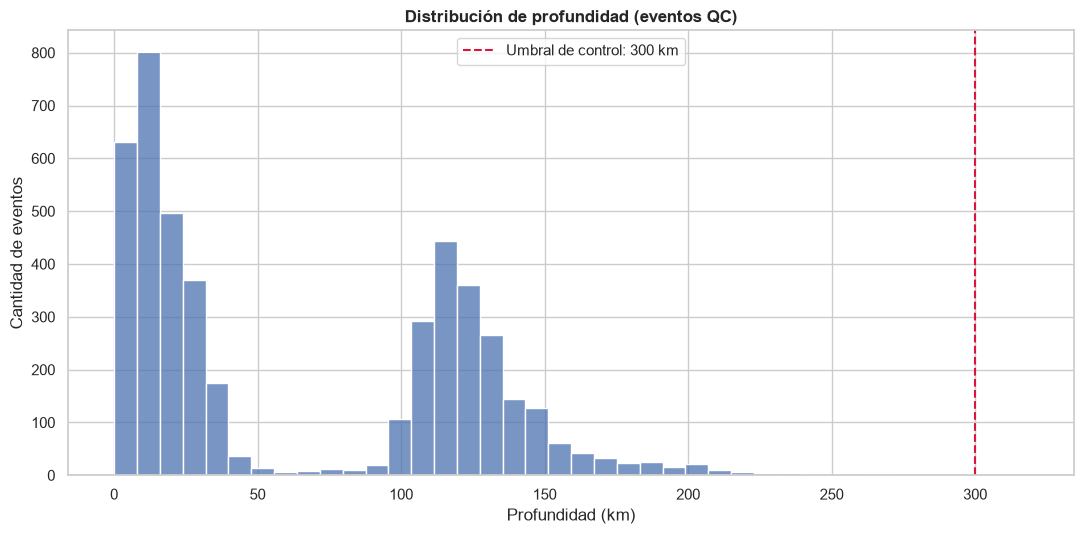

In [ ]:
depth_values = catalog_qc['depth_km'].dropna()
display(depth_values.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame('depth_km'))

fig, ax = plt.subplots()
sns.histplot(depth_values, bins=40, edgecolor='white', ax=ax)
ax.axvline(300, color='crimson', linestyle='--', label='Umbral de control: 300 km')
ax.set(title='Distribución de profundidad (eventos QC)', xlabel='Profundidad (km)', ylabel='Cantidad de eventos')
ax.legend()
plt.tight_layout()
plt.show()

# La media de profundidad es mayor que la mediana debido a la presencia
# de eventos profundos que generan una distribución asimétrica.

# Analizamos la profundidad sobre eventos que pasan el QC general.
# Se mantienen los valores extremos para no perder trazabilidad.

# La línea de 300 km es un umbral de revisión de valores extremos,
# no un criterio automático de eliminación.

# Los valores de profundidad iguales a 0 km se conservan tal como fueron
# reportados por la fuente; no se interpretan necesariamente como un
# hipocentro ubicado exactamente en la superficie.


,eventos,porcentaje
categoria,,
< 0 km (anomalía),0,0.000
0–30 km,2269,49.081
30–70 km,294,6.360
70–300 km,2058,44.517
> 300 km,2,0.043
Faltante,0,0.000


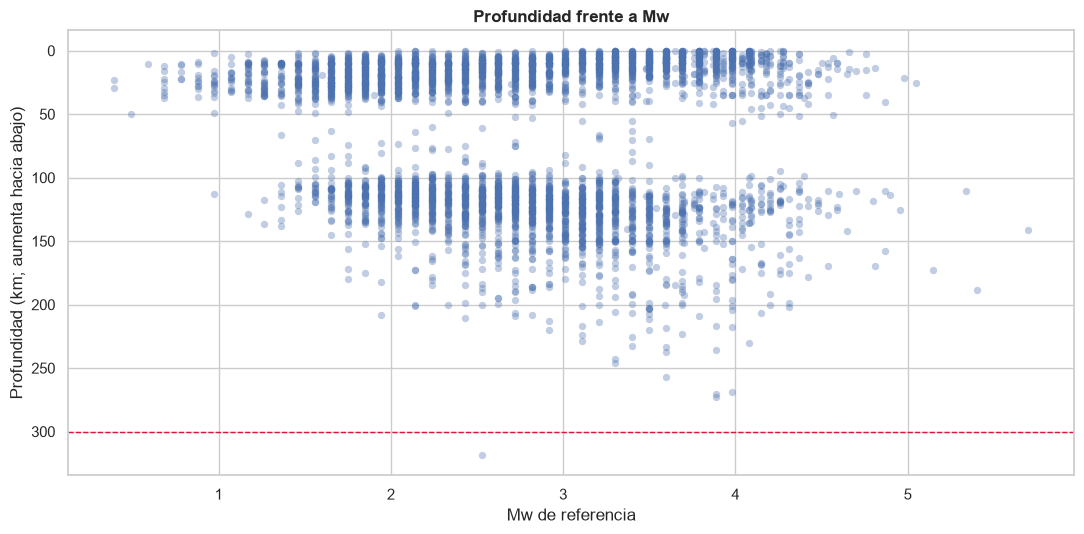

In [ ]:
depth_category = np.select(
    [
        catalog['depth_km'].lt(0),
        catalog['depth_km'].between(0, 30, inclusive='both'),
        catalog['depth_km'].gt(30) & catalog['depth_km'].le(70),
        catalog['depth_km'].gt(70) & catalog['depth_km'].le(300),
        catalog['depth_km'].gt(300),
    ],
    ['< 0 km (anomalía)', '0–30 km', '30–70 km', '70–300 km', '> 300 km'],
    default='Faltante',
)
depth_order = ['< 0 km (anomalía)', '0–30 km', '30–70 km', '70–300 km', '> 300 km', 'Faltante']
depth_counts = pd.Series(depth_category, name='categoria').value_counts().reindex(depth_order, fill_value=0).to_frame('eventos')
depth_counts['porcentaje'] = 100 * depth_counts['eventos'] / len(catalog)
display(depth_counts)

scatter_depth = catalog_mw.dropna(subset=['depth_km', 'mw_reference'])
fig, ax = plt.subplots()
sns.scatterplot(data=scatter_depth, x='mw_reference', y='depth_km', alpha=0.35, s=28, linewidth=0, ax=ax)
ax.axhline(300, color='crimson', linestyle='--', linewidth=1)
ax.invert_yaxis()
ax.set(title='Profundidad frente a Mw', xlabel='Mw de referencia', ylabel='Profundidad (km; aumenta hacia abajo)')
plt.tight_layout()
plt.show()


# Una alcaracion es que invertimos el eje Y para que una mayor profundidad se represente visualmente hacia abajo.

## 7. Fuentes


,Catálogo completo,Subconjunto Mw
sources,,
ISC,3490,3419
USGS,35,31
ISC + USGS,1098,1073


sources,ISC,USGS,ISC + USGS
año,,,
2000,17,8,60
2001,18,1,154
2002,31,2,139
2003,29,1,120
2004,35,2,92
2005,50,0,113
2006,43,2,107
2007,27,2,84
2008,40,3,46


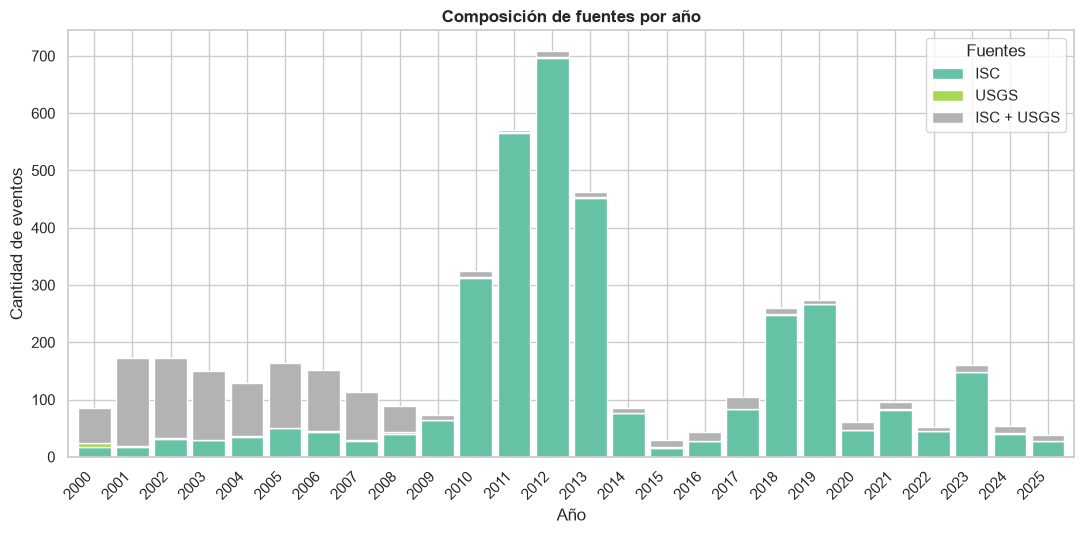

In [ ]:

# Analizamos la procedencia de los eventos para conocer la composición
# del catálogo unificado y conservar la trazabilidad hacia ISC y USGS.

# 'sources' indica en qué catálogos apareció originalmente el evento.
# ISC + USGS representa un evento identificado y fusionado entre ambas fuentes.

# 'primary_source' indica qué catálogo fue utilizado como referencia
# principal al construir el registro unificado.

source_order = ['ISC', 'USGS', 'ISC + USGS']
source_comparison = pd.DataFrame({
    'Catálogo completo': catalog['sources'].value_counts(),
    'Subconjunto Mw': catalog_mw['sources'].value_counts(),
}).reindex(source_order, fill_value=0).astype(int)
display(source_comparison)

source_by_year = pd.crosstab(catalog['time_utc'].dt.year, catalog['sources']).reindex(
    index=year_index, columns=source_order, fill_value=0
)
display(source_by_year)
ax = source_by_year.plot(kind='bar', stacked=True, width=0.86, colormap='Set2')
ax.set(title='Composición de fuentes por año', xlabel='Año', ylabel='Cantidad de eventos')
ax.legend(title='Fuentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# La cantidad de registros por fuente no debe interpretarse como una
# comparación directa de calidad entre ISC y USGS.


## 8. Visualización espacial inicial

> Estas figuras son visualizaciones exploratorias de epicentros. No son mapas de riesgo, peligrosidad ni amenaza sísmica, y no incorporan exposición, vulnerabilidad, recurrencia, incertidumbre de localización ni un modelo tectónico. No se descargan mapas base ni se consultan servicios externos.


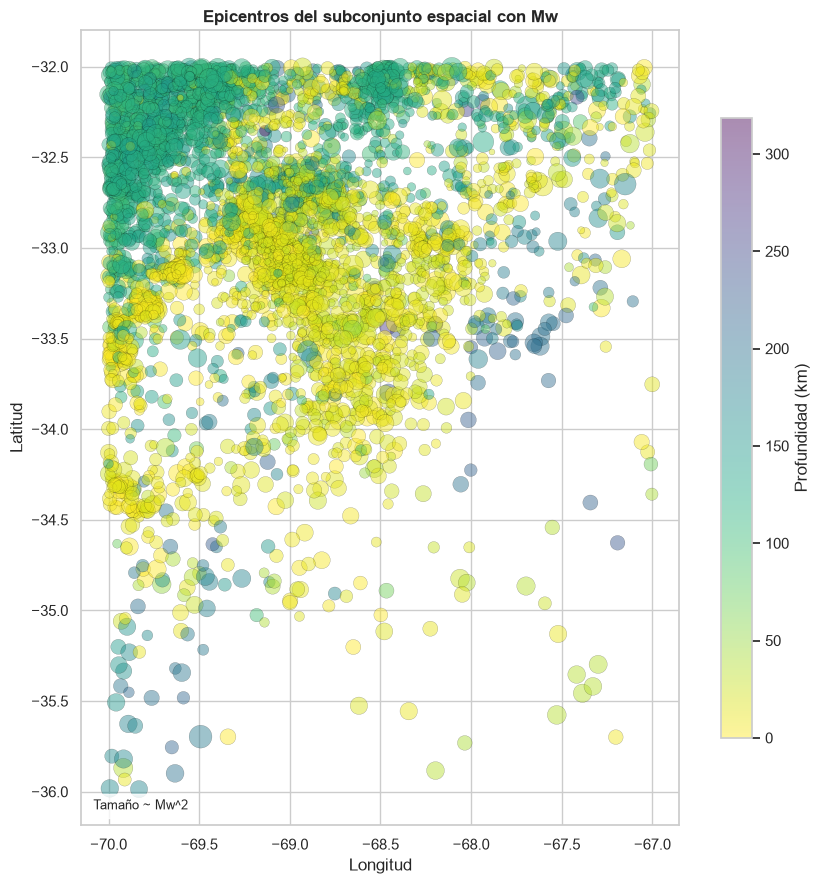

In [ ]:
spatial_mw = catalog.loc[spatial_valid_mask & mw_ready_mask].dropna(
    subset=['longitude', 'latitude', 'mw_reference', 'depth_km']
).copy()
point_sizes = 8 + 9 * np.square(spatial_mw['mw_reference'].clip(lower=0))

fig, ax = plt.subplots(figsize=(9, 9))
points = ax.scatter(
    spatial_mw['longitude'], spatial_mw['latitude'],
    s=point_sizes, c=spatial_mw['depth_km'], cmap='viridis_r',
    alpha=0.45, linewidths=0.2, edgecolors='black',
)
colorbar = fig.colorbar(points, ax=ax, shrink=0.78)
colorbar.set_label('Profundidad (km)')
ax.set(
    title='Epicentros del subconjunto espacial con Mw',
    xlabel='Longitud', ylabel='Latitud', aspect='equal',
)
ax.text(0.02, 0.02, 'Tamaño ~ Mw^2', transform=ax.transAxes, fontsize=9, bbox={'facecolor': 'white', 'alpha': 0.8})
plt.tight_layout()
plt.show()

# Para la visualización espacial usamos únicamente eventos con posición
# válida, Mw utilizable y datos completos de coordenadas y profundidad.

# Cada punto representa un evento sísmico, el color indica la profundidad y el tamaño del punto es proporcional al cuadrado de la magnitud de momento (Mw).
# Mw pequeña --> puntos pequeños, Mw grande --> puntos grandes.
# El color indica la profundidad: colores más claros representan eventos superficiales, mientras que colores más oscuros representan eventos más profundos.



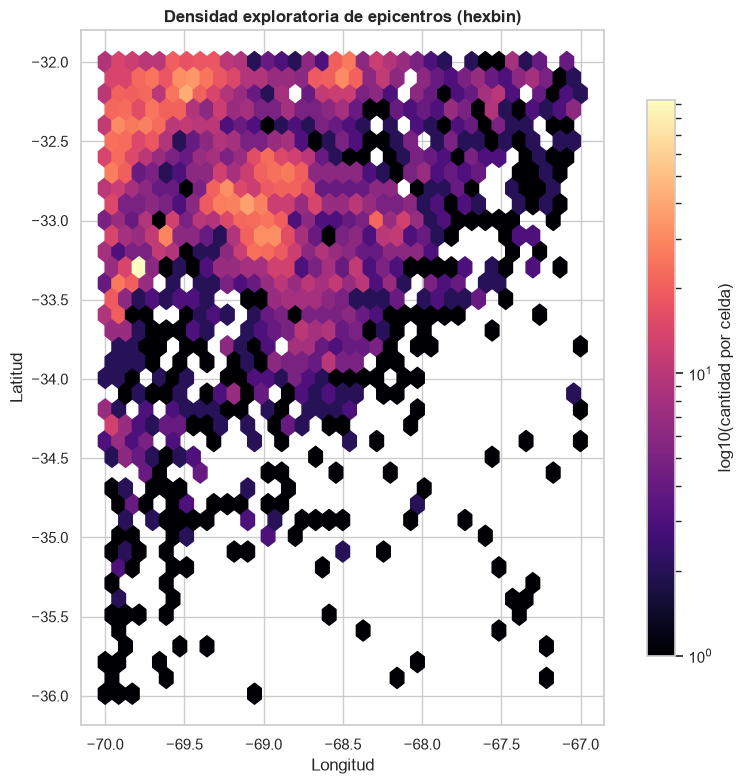

In [ ]:
fig, ax = plt.subplots(figsize=(9, 8))
density = ax.hexbin(
    catalog_spatial['longitude'], catalog_spatial['latitude'],
    gridsize=35, mincnt=1, cmap='magma', bins='log',
)
colorbar = fig.colorbar(density, ax=ax, shrink=0.8)
colorbar.set_label('log10(cantidad por celda)')
ax.set(title='Densidad exploratoria de epicentros (hexbin)', xlabel='Longitud', ylabel='Latitud', aspect='equal')
plt.tight_layout()
plt.show()

# El hexbin agrupa los epicentros en celdas hexagonales y cuenta
# cuántos eventos caen en cada una. El color usa escala logarítmica
# para representar mejor zonas con densidades muy diferentes.
# Es una visualización exploratoria, no un mapa formal de peligrosidad.


## 9. Preparación para estimar la magnitud de completitud (Mc)

Se construyen frecuencias no acumuladas y acumuladas para el subconjunto analítico Mw. La estimación **MAXC** toma como Mc el centro del intervalo con mayor frecuencia no acumulada. Para reducir errores de punto flotante, los centros y bordes se generan primero como índices enteros y recién después se convierten a magnitud.

MAXC es una aproximación exploratoria sensible al ancho y al origen de los intervalos. Antes de usar Mc en inferencia sismológica deberá validarse con métodos como GFT (Goodness-of-Fit Test) o EMR (Entire Magnitude Range), además de revisar estabilidad temporal y espacial.

> Mc representa la magnitud mínima a partir de la cual el catálogo se considera suficientemente completo para análisis de frecuencia.

> MAXC proporciona una primera estimación exploratoria de Mc buscando el intervalo de magnitud con mayor frecuencia de eventos.

In [ ]:

def frequency_magnitude(values: pd.Series | np.ndarray, bin_width: float) -> pd.DataFrame:
    if bin_width <= 0:
        raise ValueError('El intervalo de magnitud debe ser positivo.')
    numeric = pd.to_numeric(pd.Series(values), errors='coerce').dropna().to_numpy(dtype=float)
    numeric = numeric[np.isfinite(numeric)]
    if numeric.size == 0:
        raise ValueError('No hay magnitudes válidas para construir la distribución.')

    scaled = numeric / bin_width
    min_center_index = int(np.floor(scaled.min()))
    max_center_index = int(np.ceil(scaled.max()))
    center_indices = np.arange(min_center_index, max_center_index + 1, dtype=np.int64)
    edge_indices = np.arange(min_center_index, max_center_index + 2, dtype=np.int64)

    centers = center_indices.astype(float) * bin_width
    edges = (edge_indices.astype(float) - 0.5) * bin_width
    counts, _ = np.histogram(numeric, bins=edges)
    cumulative = np.cumsum(counts[::-1])[::-1]
    return pd.DataFrame({
        'magnitud_centro': centers,
        'frecuencia': counts,
        'frecuencia_acumulada': cumulative,
    })


def estimate_maxc(values: pd.Series | np.ndarray, bin_width: float) -> tuple[float, pd.DataFrame]:
    distribution = frequency_magnitude(values, bin_width)
    max_position = int(distribution['frecuencia'].to_numpy().argmax())
    mc = float(distribution.iloc[max_position]['magnitud_centro'])
    return mc, distribution


MAXC exploratorio total (ΔM = 0,1): Mw 1.8


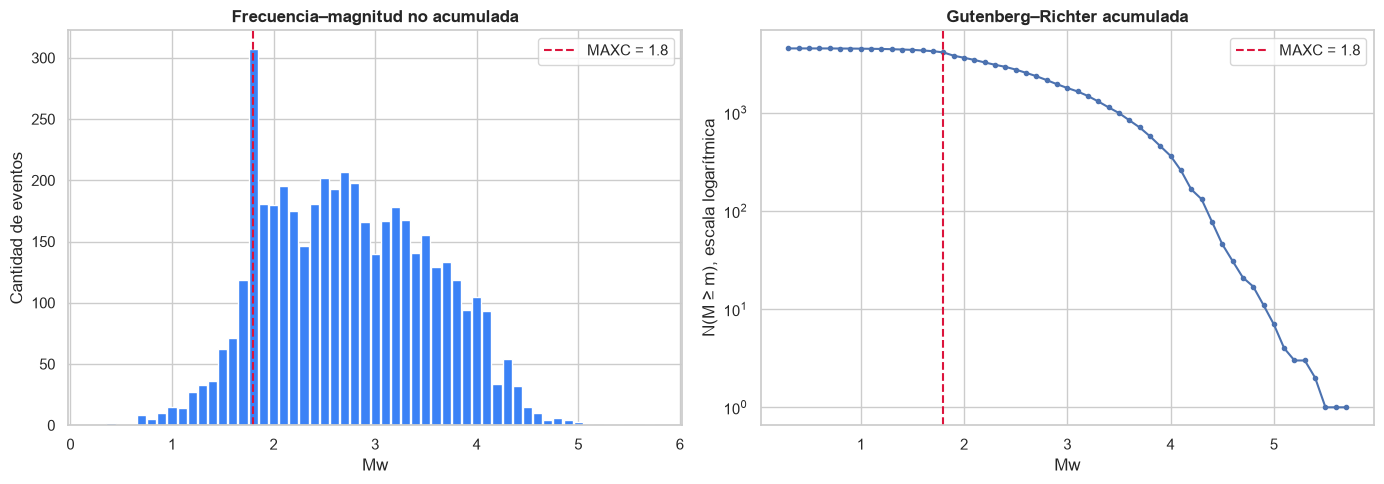

In [ ]:
mc_total_01, fm_total_01 = estimate_maxc(catalog_mw['mw_reference'], 0.1)
print(f'MAXC exploratorio total (ΔM = 0,1): Mw {mc_total_01:.1f}')

# El Mc obtenido por MAXC NO se considera definitivo.
# Posteriormente se validará con métodos como GFT/EMR y se evaluará
# su estabilidad temporal y espacial.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(fm_total_01['magnitud_centro'], fm_total_01['frecuencia'], width=0.09, color='#3b82f6')
axes[0].axvline(mc_total_01, color='crimson', linestyle='--', label=f'MAXC = {mc_total_01:.1f}')
axes[0].set(title='Frecuencia–magnitud no acumulada', xlabel='Mw', ylabel='Cantidad de eventos')
axes[0].legend()

positive_cumulative = fm_total_01['frecuencia_acumulada'].gt(0)
axes[1].semilogy(
    fm_total_01.loc[positive_cumulative, 'magnitud_centro'],
    fm_total_01.loc[positive_cumulative, 'frecuencia_acumulada'],
    marker='o', markersize=3, linewidth=1.5,
)
axes[1].axvline(mc_total_01, color='crimson', linestyle='--', label=f'MAXC = {mc_total_01:.1f}')
axes[1].set(title='Gutenberg–Richter acumulada', xlabel='Mw', ylabel='N(M ≥ m), escala logarítmica')
axes[1].legend()
plt.tight_layout()
plt.show()


# El futuro análisis de densidad y modelado utilizará eventos por encima
# de un Mc validado para reducir sesgos por detección incompleta.

In [22]:
periods = [
    ('Total', None, None),
    ('2000–2004', 2000, 2004),
    ('2005–2009', 2005, 2009),
    ('2010–2014', 2010, 2014),
    ('2015–2019', 2015, 2019),
    ('2020–2025', 2020, 2025),
]
bin_widths = [0.1, 0.2, 0.3]
sensitivity_rows = []
analysis_year = catalog_mw['time_utc'].dt.year

for period_label, start_year, end_year in periods:
    if start_year is None:
        period_values = catalog_mw['mw_reference']
    else:
        period_values = catalog_mw.loc[analysis_year.between(start_year, end_year), 'mw_reference']
    for bin_width in bin_widths:
        mc_value, distribution = estimate_maxc(period_values, bin_width)
        sensitivity_rows.append({
            'periodo': period_label,
            'eventos_mw': int(period_values.notna().sum()),
            'intervalo_magnitud': bin_width,
            'maxc_mw': mc_value,
            'frecuencia_en_maxc': int(distribution['frecuencia'].max()),
        })

maxc_sensitivity = pd.DataFrame(sensitivity_rows)
display(maxc_sensitivity)
display(maxc_sensitivity.pivot(index='periodo', columns='intervalo_magnitud', values='maxc_mw'))


,periodo,eventos_mw,intervalo_magnitud,maxc_mw,frecuencia_en_maxc
0,Total,4523,0.100,1.800,307
1,Total,4523,0.200,3.400,462
2,Total,4523,0.300,1.800,607
3,2000–2004,673,0.100,3.700,66
4,2000–2004,673,0.200,3.400,149
5,2000–2004,673,0.300,3.600,156
6,2005–2009,584,0.100,3.100,47
7,2005–2009,584,0.200,3.400,122
8,2005–2009,584,0.300,3.300,122
9,2010–2014,2152,0.100,1.800,208


intervalo_magnitud,0.100,0.200,0.300
periodo,,,
2000–2004,3.700,3.400,3.600
2005–2009,3.100,3.400,3.300
2010–2014,1.800,2.200,1.800
2015–2019,1.800,1.800,1.800
2020–2025,2.800,2.800,2.700
Total,1.800,3.400,1.800


### Lectura preliminar de MAXC

Las diferencias entre períodos y anchos de intervalo cuantifican parte de la sensibilidad de MAXC. No deben atribuirse solamente a la física de la sismicidad: la composición ISC/USGS, la evolución de la red, el reporte de eventos pequeños y las conversiones de magnitud también pueden desplazar el máximo.


## 10. Verificación de integridad de la entrada

Se vuelve a calcular el hash del CSV al final. Una ejecución correcta debe conservar exactamente el mismo SHA-256.


In [23]:
csv_sha256_after = sha256_file(CSV_PATH)
if csv_sha256_after != csv_sha256_before:
    raise RuntimeError('El CSV cambió durante la ejecución del notebook.')
print(f'CSV sin cambios. SHA-256 final: {csv_sha256_after}')
print('Análisis exploratorio completado sin modificar el dataset de entrada.')


CSV sin cambios. SHA-256 final: 702b71e1789967881dc380ca5aea02c279863e7bf00df256454ad142cf3ae228
Análisis exploratorio completado sin modificar el dataset de entrada.
